# Seismic Weather Tutorial

### Simon Ramirez

This Jupyter Notebook details how to use the wind.py file from the GitHub Repository https://github.com/Ramirezs873/seismic-weather.

Also see: https://github.com/Ramirezs873/seismic-sensor-analysis. The align.py file is recomended for this process and required for this tutorial.

ObsPy is needed for this process. https://github.com/obspy/obspy.

## 0. Imports

In [1]:
import wind
import align
from obspy import UTCDateTime as UTC
import yaml

ModuleNotFoundError: No module named 'align'

## 1. Setup config.yaml

config.yaml requries two inputs for access to both the seismic and AWS data.

Format:


seismic_data_path: "seismic_data_folder"

aws_data_path: "aws_data_folder"



In [2]:
# Add path to config.yaml file
config_path = ###
with open(config_path, "r") as f:
    config = yaml.safe_load(f)

# Define as variables
seismic_path = config["seismic_data_path"]
aws_path = config["aws_data_path"]

SyntaxError: invalid syntax (114836335.py, line 2)

## 2. Read Data

In [3]:
# AWS Data
runway = wind.read_data(path=aws_path, station_code='300050', id_code='55510926053')
skiway = wind.read_data(path=aws_path, station_code='300060', id_code='55510926053')
casy = wind.read_data(path=aws_path, station_code='300017', id_code='55510926053')

# Seismic Data
# Inputs
client1 = "IRIS"
network1 = "IU"
station1 = "CASY"
location1 = "00"
channel1 = "BH?"
t_start = UTC(2022, 12, 25, 0, 0,0)
t_end = UTC(2022, 12, 30, 0, 0, 0)
user1 = None
password1 = None


NameError: name 'aws_path' is not defined

In [4]:
# Gather data
seismic_data = align.seismic_data(client1,
                                  network1, 
                                  station1, 
                                  location1, 
                                  channel1, 
                                  t_start, 
                                  t_end,
                                  user1,
                                  password1,
                                  config=config)

NameError: name 'align' is not defined

## 3. Wind Speed and Direction

In [32]:
# Variables
data = skiway
year=2022
month=12 
day=(25,29) # Super calm (25th) to Super Stormy (29th)
hour=None
apply_smooth=False
smoothie = 3


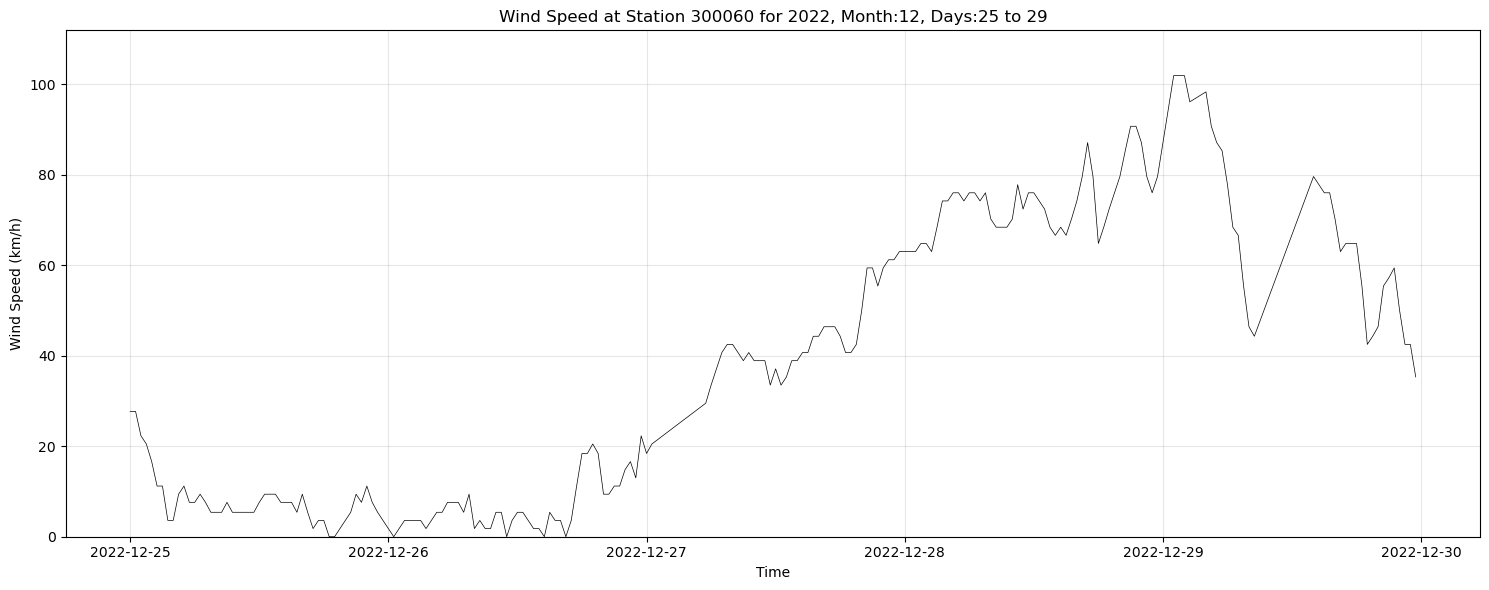

In [33]:
wind.plot_wind_speed(data, 
                    year, 
                    month, 
                    day,
                    hour,
                    apply_smooth,
                    smoothie)

In [34]:
wind.plot_rose_wind(data, 
                    year, 
                    month,
                    day,
                    hour)

C:\Users\simon\Desktop\UTAS\Honours Research\GitHub\seismic-weather\wind.py:278: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



## 4. Compare Wind and Seismic Data

See align.py tutorial for seismic preprocessing information.

Processing IU.CASY.00...


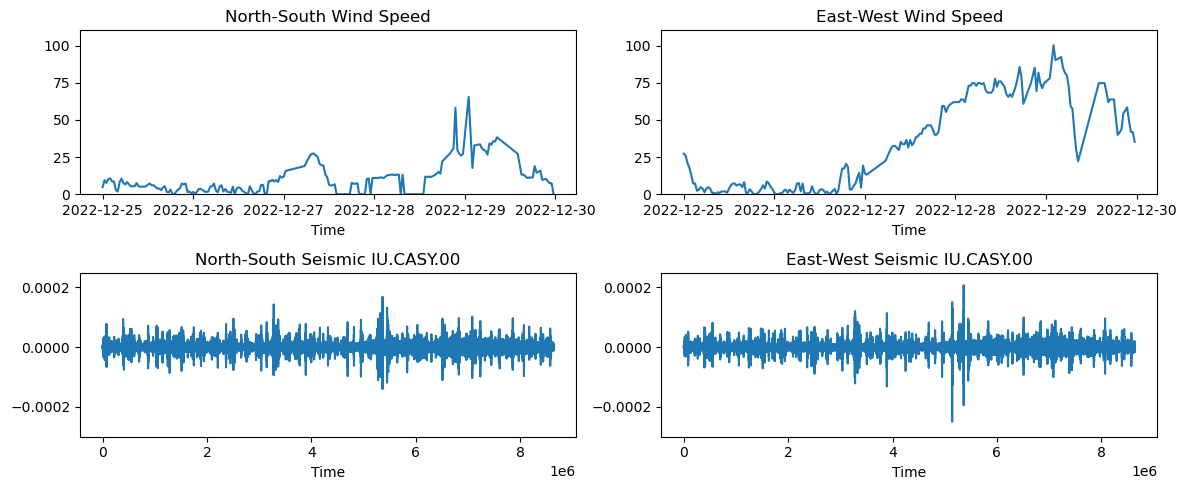

In [37]:
#Casy and skiway
#Prepocessing
win = align.apply_window(seismic_data, type='hann', side='both', max_length=180)
filt = align.apply_filter(win, filter_type='highpass', freq = 5, corners=4)
angle_list =[0]
aligned = align.rotate_stream(filt, NS_channel=["BH1"], EW_channel=["BH2"], misalignment_angle=angle_list, plot = False) # Polar plot will break if too many large samples. View shorter time periods or resample down
#align.plot_psd(aligned, 20)
#align.plot_spectrogram(aligned, 20) # Spectrogram will break if too many samples. View shorter time periods or resample down

wind.compare_seismic_wind(aligned, skiway, wind_year=year, wind_month=month, wind_day=day, wind_hour=hour, 
                          apply_wind_smooth = False, wind_smoothie = 5, 
                          apply_seismic_smooth = True, seismic_smoothie = 2000,
                          rectify_seis = False)


## 5. Compare Wind and Seismic Noise Data

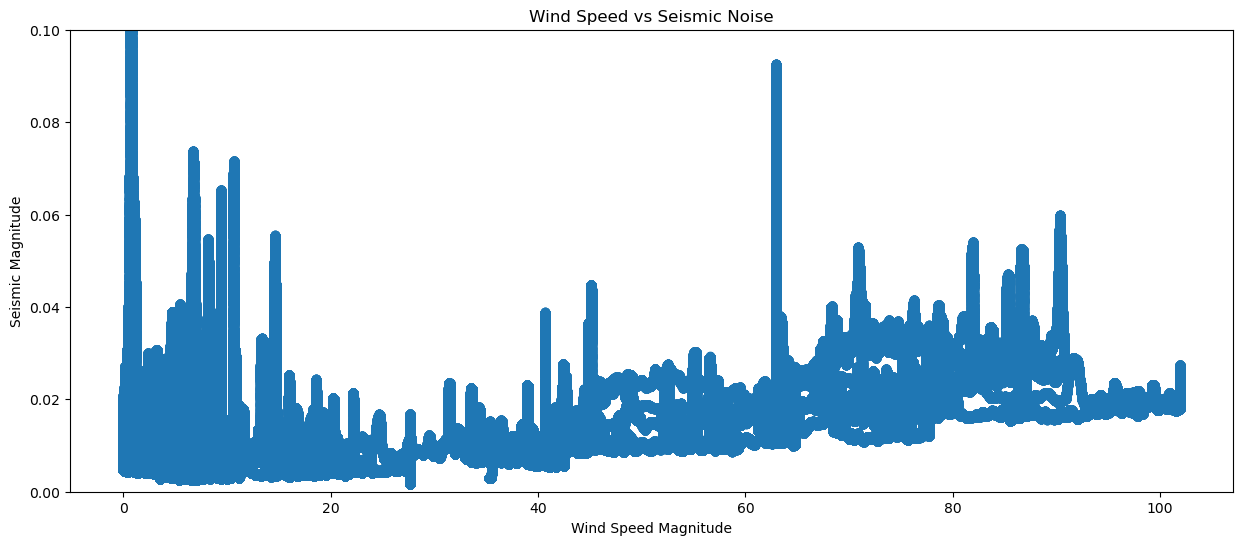

In [38]:
wind.wind_vs_noise(aligned, skiway, wind_year=year, wind_month=month, wind_day=day, wind_hour=hour, 
                   apply_smooth = True, smoothie = 1000)